In [2]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
%matplotlib inline


In [3]:
DATA_DIR = '../ml-32m'

movie_data = pd.read_csv(os.path.join(DATA_DIR, 'movies.csv'))
rating_data = pd.read_csv(os.path.join(DATA_DIR, 'ratings.csv'))
movie_link_data = pd.read_csv(os.path.join(DATA_DIR, 'links.csv'))
tag_data = pd.read_csv(os.path.join(DATA_DIR, 'tags.csv'))


In [4]:

print(f'shape of MOVIE dataset is',movie_data.shape)
print("-----------------------------------------")
print(f'unique movieid no.',movie_data['movieId'].nunique())
print("-----------------------------------------")
print(movie_data.isnull().sum())
print("-----------------------------------------")
print(movie_data.describe())
print("-----------------------------------------")
movie_data.head()


shape of MOVIE dataset is (87585, 3)
-----------------------------------------
unique movieid no. 87585
-----------------------------------------
movieId    0
title      0
genres     0
dtype: int64
-----------------------------------------
             movieId
count   87585.000000
mean   157651.365519
std     79013.402099
min         1.000000
25%    112657.000000
50%    165741.000000
75%    213203.000000
max    292757.000000
-----------------------------------------


,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


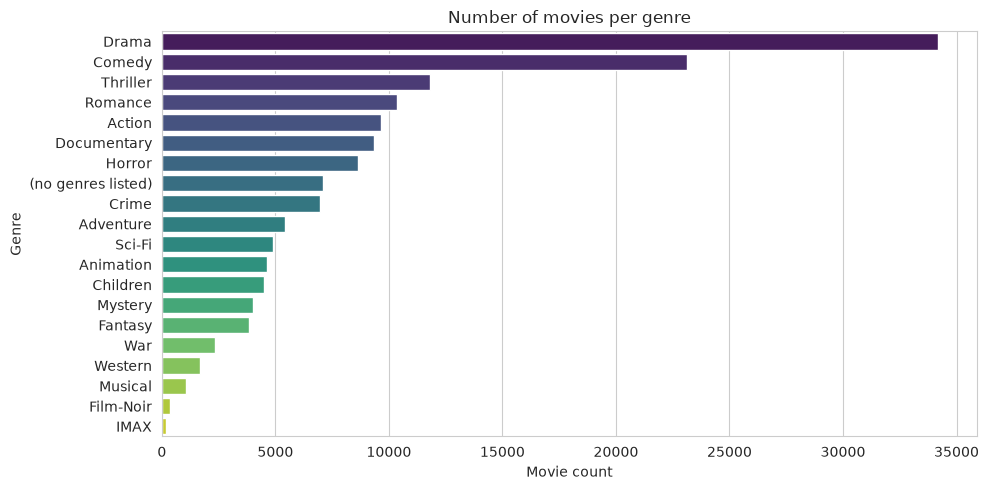

In [5]:
# Genre distribution - how many movies fall in each genre
genre_series = movie_data['genres'].str.split('|').explode()
genre_counts = genre_series.value_counts()

plt.figure(figsize=(10, 5))
sns.barplot(x=genre_counts.values, y=genre_counts.index, hue=genre_counts.index, palette='viridis', legend=False)
plt.title('Number of movies per genre')
plt.xlabel('Movie count')
plt.ylabel('Genre')
plt.tight_layout()
plt.show()


In [6]:
print(f'shape of MOVIE dataset is',rating_data.shape)
print("-----------------------------------------")
print(f'unique movieid no.',rating_data['movieId'].nunique())
print("-----------------------------------------")
print(rating_data.isnull().sum())
print("-----------------------------------------")
print(rating_data.describe())
print("-----------------------------------------")
rating_data.head()


shape of MOVIE dataset is (32000204, 4)
-----------------------------------------
unique movieid no. 84432
-----------------------------------------
userId       0
movieId      0
rating       0
timestamp    0
dtype: int64
-----------------------------------------
             userId       movieId        rating     timestamp
count  3.200020e+07  3.200020e+07  3.200020e+07  3.200020e+07
mean   1.002785e+05  2.931861e+04  3.540396e+00  1.275241e+09
std    5.794905e+04  5.095816e+04  1.058986e+00  2.561630e+08
min    1.000000e+00  1.000000e+00  5.000000e-01  7.896520e+08
25%    5.005300e+04  1.233000e+03  3.000000e+00  1.051012e+09
50%    1.002970e+05  3.452000e+03  3.500000e+00  1.272622e+09
75%    1.504510e+05  4.419900e+04  4.000000e+00  1.503158e+09
max    2.009480e+05  2.927570e+05  5.000000e+00  1.697164e+09
-----------------------------------------


,userId,movieId,rating,timestamp
0,1,17,4.0,944249077
1,1,25,1.0,944250228
2,1,29,2.0,943230976
3,1,30,5.0,944249077
4,1,32,5.0,943228858


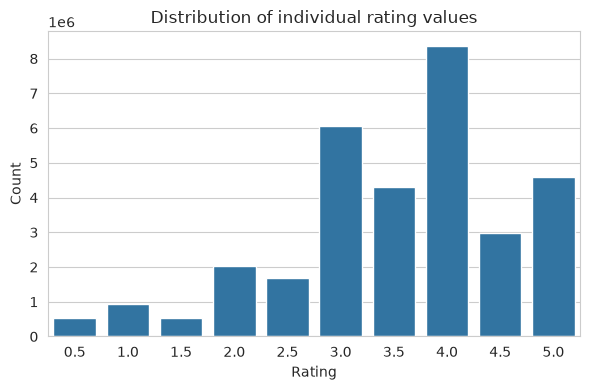

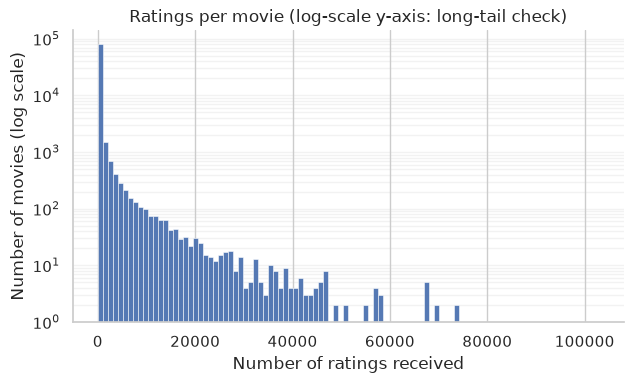

Movies with only 1 rating: 18607
Movies with 1000+ ratings: 4397


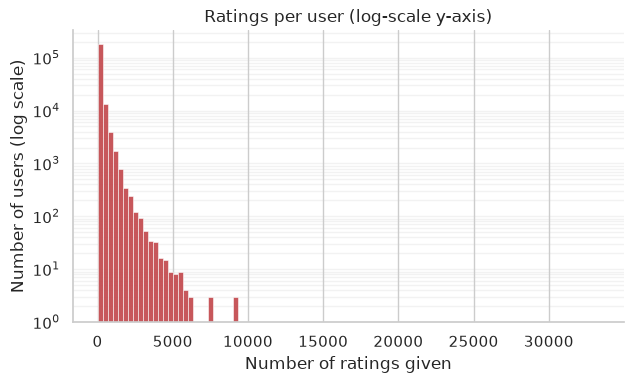

In [7]:
# How users rate movies - is 3.5-4.0 the norm, or is it spread out?
plt.figure(figsize=(6, 4))
sns.countplot(x=rating_data['rating'])
plt.title('Distribution of individual rating values')
plt.xlabel('Rating')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

# Ratings-per-movie: this is expected to be long-tailed (a few blockbusters get
# most of the ratings, most movies get very few). This long tail is exactly why
# a raw average rating is a bad ranking signal (see popularity_score below) -
# a movie with 3 ratings of 5.0 would otherwise outrank a movie with 50,000
# ratings averaging 4.5.
sns.set_theme(style='whitegrid', context='notebook')
ratings_per_movie = rating_data.groupby('movieId').size()

fig, ax = plt.subplots(figsize=(6.5, 4))
ax.hist(ratings_per_movie, bins=100, color='#4C72B0', edgecolor='white', linewidth=0.4, alpha=0.95)
ax.set_yscale('log')
ax.set_ylim(bottom=1)
ax.set_title('Ratings per movie (log-scale y-axis: long-tail check)')
ax.set_xlabel('Number of ratings received')
ax.set_ylabel('Number of movies (log scale)')
ax.grid(axis='y', which='both', alpha=0.25)
sns.despine(ax=ax)
fig.tight_layout()
plt.show()

print('Movies with only 1 rating:', (ratings_per_movie == 1).sum())
print('Movies with 1000+ ratings:', (ratings_per_movie >= 1000).sum())

# Ratings-per-user: are most users light raters, with a few power raters?
ratings_per_user = rating_data.groupby('userId').size()

fig, ax = plt.subplots(figsize=(6.5, 4))
ax.hist(ratings_per_user, bins=100, color='#C44E52', edgecolor='white', linewidth=0.4, alpha=0.95)
ax.set_yscale('log')
ax.set_ylim(bottom=1)
ax.set_title('Ratings per user (log-scale y-axis)')
ax.set_xlabel('Number of ratings given')
ax.set_ylabel('Number of users (log scale)')
ax.grid(axis='y', which='both', alpha=0.25)
sns.despine(ax=ax)
fig.tight_layout()
plt.show()

In [8]:
print(f'shape of MOVIE dataset is',tag_data.shape)
print("-----------------------------------------")
print(f'unique movieid no.',tag_data['movieId'].nunique())
print("-----------------------------------------")
print(tag_data.isnull().sum())
print("-----------------------------------------")
print(tag_data.describe())
print("-----------------------------------------")
tag_data.head()



shape of MOVIE dataset is (2000072, 4)
-----------------------------------------
unique movieid no. 51323
-----------------------------------------
userId        0
movieId       0
tag          17
timestamp     0
dtype: int64
-----------------------------------------
             userId       movieId     timestamp
count  2.000072e+06  2.000072e+06  2.000072e+06
mean   8.192859e+04  7.189326e+04  1.528914e+09
std    3.810650e+04  7.480379e+04  1.290835e+08
min    2.200000e+01  1.000000e+00  1.135429e+09
25%    6.841300e+04  4.011000e+03  1.473615e+09
50%    7.821300e+04  5.232800e+04  1.574071e+09
75%    1.036980e+05  1.222940e+05  1.614740e+09
max    1.622790e+05  2.926290e+05  1.697155e+09
-----------------------------------------


,userId,movieId,tag,timestamp
0,22,26479,Kevin Kline,1583038886
1,22,79592,misogyny,1581476297
2,22,247150,acrophobia,1622483469
3,34,2174,music,1249808064
4,34,2174,weird,1249808102


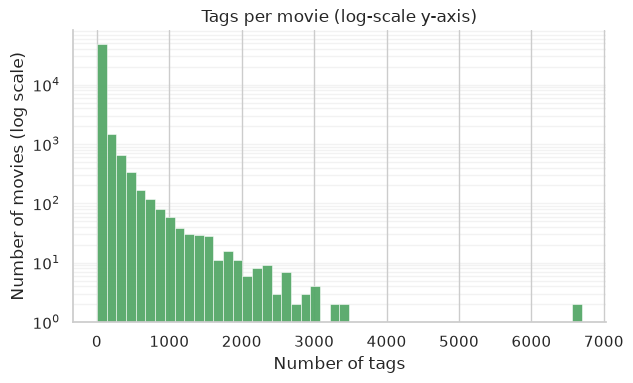

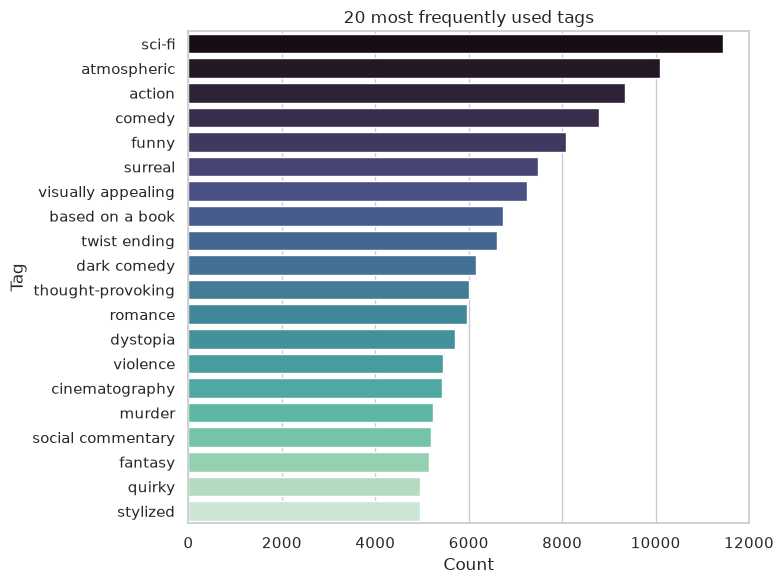

In [9]:
# How many tags does a movie typically get, and what are the most common tags?
tag_counts = tag_data.groupby('movieId').size()

sns.set_theme(style='whitegrid', context='notebook')
fig, ax = plt.subplots(figsize=(6.5, 4))
ax.hist(tag_counts, bins=50, color='#55A868', edgecolor='white', linewidth=0.4, alpha=0.95)
ax.set_yscale('log')
ax.set_ylim(bottom=1)
ax.set_title('Tags per movie (log-scale y-axis)')
ax.set_xlabel('Number of tags')
ax.set_ylabel('Number of movies (log scale)')
ax.grid(axis='y', which='both', alpha=0.25)
sns.despine(ax=ax)
fig.tight_layout()
plt.show()

top_tags = tag_data['tag'].str.lower().value_counts().head(20)
fig, ax = plt.subplots(figsize=(8, 6))
sns.barplot(x=top_tags.values, y=top_tags.index, hue=top_tags.index, palette='mako', legend=False, ax=ax)
ax.set_title('20 most frequently used tags')
ax.set_xlabel('Count')
ax.set_ylabel('Tag')
fig.tight_layout()
plt.show()

In [10]:
tag_data.dropna(inplace=True,axis=0)
print(f'shape of tag data',tag_data.shape)

shape of tag data (2000055, 4)


In [11]:
tags_grouped = tag_data.groupby('movieId')['tag'].agg(
    tags=lambda x: " ".join(x),
    tag_count='count'
).reset_index()

In [12]:
tags_grouped

,movieId,tags,tag_count
0,1,children Disney animation children Disney Disn...,1230
1,2,Robin Williams fantasy Robin Williams time tra...,573
2,3,comedinha de velhinhos engraÃƒÂ§ada comedinha ...,23
3,4,characters slurs based on novel or book chick ...,12
4,5,Fantasy pregnancy remake family Steve Martin s...,64
...,...,...,...
51318,292143,Cadaqués catalonia China housing estate husban...,12
51319,292349,politically incorrect,1
51320,292371,Stephen King,1
51321,292597,artificial intelligence,1


In [13]:
movie_rating = rating_data.groupby('movieId')['rating'].agg(['mean','count']).reset_index()
movie_rating.columns = ['movieId','average_rating','rating_count']
movie_rating.head()

,movieId,average_rating,rating_count
0,1,3.897438,68997
1,2,3.275758,28904
2,3,3.139447,13134
3,4,2.845331,2806
4,5,3.059602,13154


### Merging movie_data, movie_rating and tags_grouped

In [14]:

merged_data = pd.merge(movie_data, movie_rating, on='movieId', how='inner')

final_dataset = pd.merge(merged_data, tags_grouped, on='movieId', how='inner')

final_dataset.head()

,movieId,title,genres,average_rating,rating_count,tags,tag_count
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,3.897438,68997,children Disney animation children Disney Disn...,1230
1,2,Jumanji (1995),Adventure|Children|Fantasy,3.275758,28904,Robin Williams fantasy Robin Williams time tra...,573
2,3,Grumpier Old Men (1995),Comedy|Romance,3.139447,13134,comedinha de velhinhos engraÃƒÂ§ada comedinha ...,23
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance,2.845331,2806,characters slurs based on novel or book chick ...,12
4,5,Father of the Bride Part II (1995),Comedy,3.059602,13154,Fantasy pregnancy remake family Steve Martin s...,64


In [15]:
final_dataset['year'] = final_dataset['title'].str.extract(r'\((\d{4})\)')
final_dataset['title'] = final_dataset['title'].str.replace(r'\(\d{4}\)','', regex=True).str.strip()
final_dataset['popularity_score'] = final_dataset['rating_count'] * np.log(final_dataset['average_rating'])
print(final_dataset.shape)

(48170, 9)


In [16]:
# final_dataset['genres'] = final_dataset['genres'].str.replace('|',' ', regex=False)
# final_dataset['genres'] =final_dataset['genres'] .str.lower()
# final_dataset['tags'] = final_dataset['tags'].str.lower()
# final_dataset['features'] = final_dataset['genres'] + " " + final_dataset['tags']
# final_dataset=final_dataset.drop(columns=['tags','genres'])


In [17]:

# final_dataset = final_dataset[final_dataset['tag_count'] > 2]
final_dataset = final_dataset[final_dataset['rating_count'] > 30]

In [18]:
final_dataset.shape

(18812, 9)

In [19]:
final_dataset

,movieId,title,genres,average_rating,rating_count,tags,tag_count,year,popularity_score
0,1,Toy Story,Adventure|Animation|Children|Comedy|Fantasy,3.897438,68997,children Disney animation children Disney Disn...,1230,1995,93857.951004
1,2,Jumanji,Adventure|Children|Fantasy,3.275758,28904,Robin Williams fantasy Robin Williams time tra...,573,1995,34296.017938
2,3,Grumpier Old Men,Comedy|Romance,3.139447,13134,comedinha de velhinhos engraÃƒÂ§ada comedinha ...,23,1995,15025.909949
3,4,Waiting to Exhale,Comedy|Drama|Romance,2.845331,2806,characters slurs based on novel or book chick ...,12,1995,2934.176838
4,5,Father of the Bride Part II,Comedy,3.059602,13154,Fantasy pregnancy remake family Steve Martin s...,64,1995,14709.917275
...,...,...,...,...,...,...,...,...,...
48117,289727,"Red, White & Royal Blue",Comedy|Drama|Romance,3.500000,45,surprisingly good romance gay homosexuality LG...,17,2023,56.374334
48129,290105,You Are So Not Invited to My Bat Mitzvah,Comedy,3.015152,33,bad acting endearing too long,3,2023,36.420453
48132,290213,The Equalizer 3,Action|Crime|Thriller,3.357143,56,Denzel Washington,1,2023,67.821055
48142,290407,No One Will Save You,Horror|Sci-Fi|Thriller,2.877193,57,aliens confusing little dialogue aliens aliens...,32,2023,60.238464


### Preprocessing

#### we will do onehot encoding for genre and tfidf vectorisation for tags 

In [20]:
from sklearn.preprocessing import OneHotEncoder
import re
from sklearn.feature_extraction.text import TfidfVectorizer


In [21]:
final_dataset

,movieId,title,genres,average_rating,rating_count,tags,tag_count,year,popularity_score
0,1,Toy Story,Adventure|Animation|Children|Comedy|Fantasy,3.897438,68997,children Disney animation children Disney Disn...,1230,1995,93857.951004
1,2,Jumanji,Adventure|Children|Fantasy,3.275758,28904,Robin Williams fantasy Robin Williams time tra...,573,1995,34296.017938
2,3,Grumpier Old Men,Comedy|Romance,3.139447,13134,comedinha de velhinhos engraÃƒÂ§ada comedinha ...,23,1995,15025.909949
3,4,Waiting to Exhale,Comedy|Drama|Romance,2.845331,2806,characters slurs based on novel or book chick ...,12,1995,2934.176838
4,5,Father of the Bride Part II,Comedy,3.059602,13154,Fantasy pregnancy remake family Steve Martin s...,64,1995,14709.917275
...,...,...,...,...,...,...,...,...,...
48117,289727,"Red, White & Royal Blue",Comedy|Drama|Romance,3.500000,45,surprisingly good romance gay homosexuality LG...,17,2023,56.374334
48129,290105,You Are So Not Invited to My Bat Mitzvah,Comedy,3.015152,33,bad acting endearing too long,3,2023,36.420453
48132,290213,The Equalizer 3,Action|Crime|Thriller,3.357143,56,Denzel Washington,1,2023,67.821055
48142,290407,No One Will Save You,Horror|Sci-Fi|Thriller,2.877193,57,aliens confusing little dialogue aliens aliens...,32,2023,60.238464


In [22]:
import pandas as pd
import numpy as np
import re

from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.feature_extraction.text import TfidfVectorizer

from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

# Load dataset
data = final_dataset

# download stopwords if needed
import nltk
nltk.download('stopwords')

# stopword + stemmer
stop_words = set(stopwords.words('english'))
stemmer = PorterStemmer()

[nltk_data] Downloading package stopwords to /home/karan/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [23]:
# clean tags function
def preprocess_tags(text):

    text = str(text).lower()
    
    text = re.sub('[^a-zA-Z ]',' ',text)

    words = text.split()

    words = [w for w in words if w not in stop_words]

    words = [stemmer.stem(w) for w in words]

    return " ".join(words)


# apply preprocessing
data['tags_clean'] = data['tags'].fillna("").apply(preprocess_tags)

In [24]:
tfidf = TfidfVectorizer(max_features=5000)

tag_matrix = tfidf.fit_transform(data['tags_clean'])

In [25]:
# Process genres
data['genres_list'] = data['genres'].apply(lambda x: str(x).split('|'))


# OneHot encode genres
mlb = MultiLabelBinarizer()
genre_matrix = mlb.fit_transform(data['genres_list'])
